# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Cuda GPU acceleration.


Read Data

In [3]:
from NNSolver import Net


K = 4
B_total = 100e3
C_DT_total = 50e6
beta_max = 3
model = Net(K, B_total, C_DT_total, beta_max)

In [4]:
from DataUtil import generate_data_loader


train_loader, test_loader = generate_data_loader(int(1e5), K, 16e3, beta_max=3.5)

In [5]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping


optimizer = Adam(model.parameters(), lr=0.01)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = EarlyStopping(patience=5, min_delta=0.1)
loss_fn = unsupervised_loss

train(model, train_loader, test_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start training
epoch: 01, avg loss: 1503.817555116438
epoch: 02, avg loss: 1503.2884276823195
epoch: 03, avg loss: 1503.7113443142823
epoch: 04, avg loss: 1503.689052687525
epoch: 05, avg loss: 1501.1184314979928
epoch: 06, avg loss: 1503.835535500858
epoch: 07, avg loss: 1503.7805484210505
epoch: 08, avg loss: 1503.6549612342167
epoch: 09, avg loss: 1503.6259705761095
epoch: 10, avg loss: 1503.6148014027935
best epoch: 05, best avg loss: 1501.118431


In [6]:
# state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
# model.to(device)
# model.load_state_dict(state_dict)

## NN

|   sensor_num |         D |    H(dB) |          b |             f |   beta |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|----------:|---------:|-----------:|--------------:|-------:|--------------:|-------------:|-----------:|-----------:|
|       0.0000 | 1000.0000 | -40.0000 | 20970.7520 |  8783975.0000 | 1.5000 |        3.3990 |       0.7873 |     1.4733 |     1.1384 |
|       1.0000 | 1000.0000 | -40.0000 | 37087.7461 | 23648080.0000 | 2.0000 |        6.8419 |       5.3176 |     1.1014 |     0.4229 |
|       2.0000 | 1000.0000 | -40.0000 | 20970.7520 |  8783975.0000 | 1.5000 |        3.3990 |       0.7873 |     1.4733 |     1.1384 |
|       3.0000 | 1000.0000 | -40.0000 | 20970.7520 |  8783975.0000 | 1.5000 |        3.3990 |       0.7873 |     1.4733 |     1.1384 |

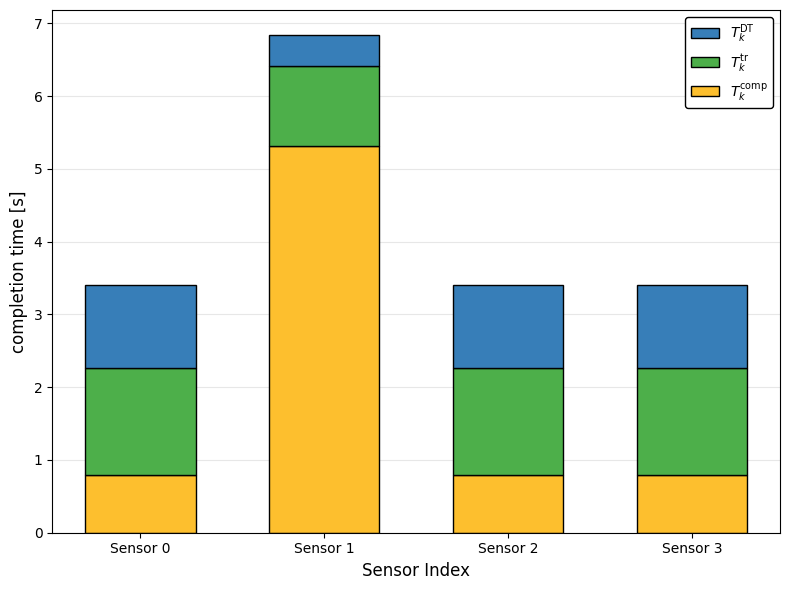

In [7]:
import TrainingUtil as tu
import DataUtil as du
import AnalyzeUtil as au
import ProcessTime as process

length=1000

H = au.to_normal(-40)

H_k = torch.tensor([H, H, H, H])
test_d = torch.tensor([1e3, 1e3, 1e3, 1e3])
test_beta = torch.tensor([1.5, 2, 1.5, 1.5])
X_test = torch.cat((test_d, H_k, test_beta)).reshape(1, -1).to('cuda')

b, f = model(X_test)

b = b.to('cpu')
f = f.to('cpu')
au.plot_result(X_test.to('cpu'), b, f)
au.print_avg(X_test.to('cpu'), b, f)


## Traditional

step=0, loss=7.221258e+00
step=100, loss=6.754570e+00
step=200, loss=6.680806e+00
step=300, loss=6.654814e+00
step=400, loss=6.659322e+00


|   sensor_num |         D |    H(dB) |          b |             f |   beta |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|----------:|---------:|-----------:|--------------:|-------:|--------------:|-------------:|-----------:|-----------:|
|       0.0000 | 1000.0000 | -40.0000 |  5878.7153 |  2768506.7500 | 1.5000 |        5.9006 |       0.7873 |     1.5013 |     3.6121 |
|       1.0000 | 1000.0000 | -40.0000 | 83324.1797 | 42057876.0000 | 2.0000 |        6.6542 |       5.3176 |     1.0988 |     0.2378 |
|       2.0000 | 1000.0000 | -40.0000 |  5533.5107 |  2638587.7500 | 1.5000 |        6.0809 |       0.7873 |     1.5037 |     3.7899 |
|       3.0000 | 1000.0000 | -40.0000 |  5263.6011 |  2535029.2500 | 1.5000 |        6.2378 |       0.7873 |     1.5058 |     3.9447 |

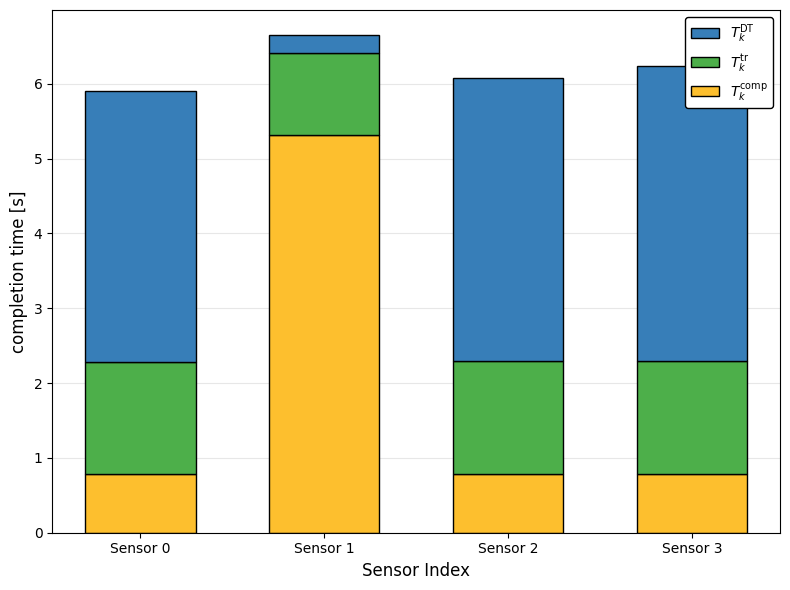

In [8]:
from TraditionalSolver import TraditionalLeaderOptimizer

leader_solver = TraditionalLeaderOptimizer(
    K=K,
    min_share=1e-4,
    dtype=torch.float32,
    device="cuda",
)

result = leader_solver.solve(
    X_test,
    steps=500,
    lr=1e-2,
    tau=None,
    optimizer_type="adam",
    verbose=True,
)

au.plot_result(X_test.to('cpu'), result["b"].to('cpu'), result['f'].to('cpu'))
au.print_avg(X_test.to('cpu'), result["b"].to('cpu'), result['f'].to('cpu'))


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Algorithm.py:98: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Algorithm.py:128: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / mu - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Algorithm.py:130: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


|         D |   H_mag(dB) |      p |   comp_speed |          b |             f |   beta |   lambda_1 |   lambda_2 |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|----------:|------------:|-------:|-------------:|-----------:|--------------:|-------:|-----------:|-----------:|--------------:|-------------:|-----------:|-----------:|
| 1000.0000 |    -40.8206 | 0.0316 |  200000.0000 |  9436.9189 |  3025058.2500 | 1.3505 |     0.0000 |     2.2289 |        7.6700 |       0.4712 |     3.1819 |     4.0169 |
| 3000.0000 |    -40.7740 | 0.0316 |  200000.0000 | 19637.1992 | 11686128.0000 | 1.3436 |     0.0000 |     6.6269 |       13.9814 |       1.3967 |     9.5359 |     3.0488 |
| 5000.0000 |    -40.7416 | 0.0316 |  200000.0000 | 28944.5742 | 15369439.0000 | 1.3429 |     0.0000 |    11.3669 |       22.7721 |       2.4198 |    16.5981 |     3.7542 |
| 7000.0000 |    -40.7360 | 0.0316 |  200000.0000 | 41981.2852 | 19919390.0000 | 1.3398 |     0.0000 |    15.1766 |       28.6997 |       3.1771 |    21.6120 |     3.9107 |

|    |   iter |   objective |          diff |   max_time_mean |   max_time_max |
|---:|-------:|------------:|--------------:|----------------:|---------------:|
|  0 |      0 |     35.0895 | inf           |         35.0895 |        837.753 |
|  1 |      1 |     34.8092 |   0.280281    |         34.8092 |        828.65  |
|  2 |      2 |     34.7967 |   0.012516    |         34.7967 |        825.251 |
|  3 |      3 |     34.7924 |   0.00429916  |         34.7924 |        822.278 |
|  4 |      4 |     34.789  |   0.0033989   |         34.789  |        821.38  |
|  5 |      5 |     34.7894 |   0.000469208 |         34.7894 |        821.452 |
|  6 |      6 |     34.7874 |   0.00201035  |         34.7874 |        819.694 |
|  7 |      7 |     34.7883 |   0.000846863 |         34.7883 |        818.737 |
|  8 |      8 |     34.7913 |   0.00304031  |         34.7913 |        821.972 |
|  9 |      9 |     34.7911 |   0.000209808 |         34.7911 |        821.81  |
| 10 |     10 |     34.791  |   0.000160217 |         34.791  |        821.68  |
| 11 |     11 |     34.7908 |   0.000125885 |         34.7908 |        821.574 |
| 12 |     12 |     34.7907 |   0.000106812 |         34.7907 |        821.487 |
| 13 |     13 |     34.7906 |   0.000148773 |         34.7906 |        821.352 |
| 14 |     14 |     34.7905 |   0.000106812 |         34.7905 |        821.262 |
| 15 |     15 |     34.7904 |   4.57764e-05 |         34.7904 |        821.216 |
| 16 |     16 |     34.7904 |   4.19617e-05 |         34.7904 |        821.179 |
| 17 |     17 |     34.7904 |   2.28882e-05 |         34.7904 |        821.153 |
| 18 |     18 |     34.7903 |   3.05176e-05 |         34.7903 |        821.129 |
| 19 |     19 |     34.7903 |   7.62939e-06 |         34.7903 |        821.117 |
| 20 |     20 |     34.7903 |   1.14441e-05 |         34.7903 |        821.108 |
| 21 |     21 |     34.7903 |   3.8147e-06  |         34.7903 |        821.1   |
| 22 |     22 |     34.7903 |   7.62939e-06 |         34.7903 |        821.097 |
| 23 |     23 |     34.7903 |   3.8147e-06  |         34.7903 |        821.089 |
| 24 |     24 |     34.7903 |   7.62939e-06 |         34.7903 |        821.089 |
| 25 |     25 |     34.7903 |   0           |         34.7903 |        821.085 |

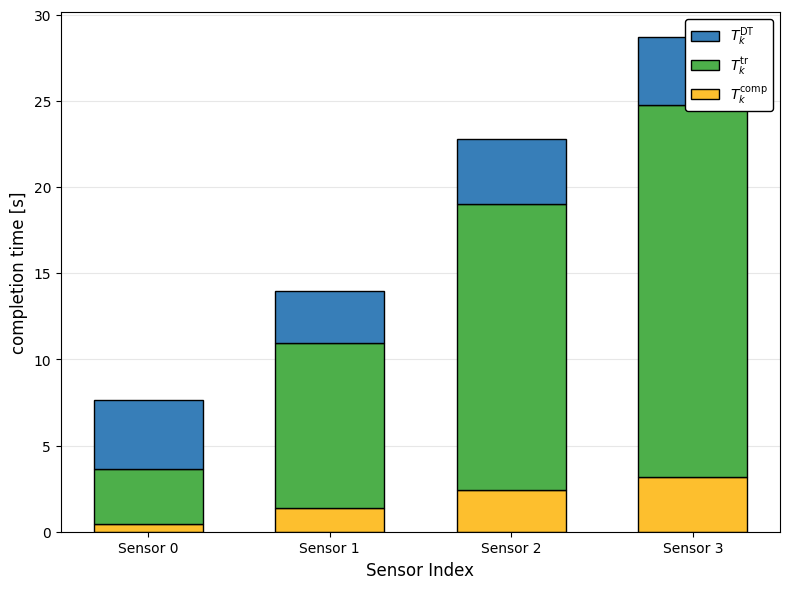

In [12]:
from Algorithm import Algorithm
from CVXLeaderModel import CVXLeaderModel
from IPython.display import display, Markdown

D = (np.array([0.25, 0.75, 1.25, 1.75]) * 4e3 ).reshape(1, -1)
D = np.repeat(D, 1000, axis=0)
H = du.generate_channel_gains(1000, 4).numpy()

algo = Algorithm(D, H)

his = algo.optimize(model, max_iters=100)
    
algo.display_df()
algo.plot()
display(Markdown(his.to_markdown()))